In [3]:
import numpy as np
print("numpy", np.__version__)
print(np.arange(6).reshape(2, 3))

numpy 2.1.3
[[0 1 2]
 [3 4 5]]


In [4]:
import numpy as np

class FakeGPU:
    def __init__(self, rank):
        self.rank = rank          # which GPU am I: 0, 1, 2, ...
        self.data = None          # the numbers I hold

g = FakeGPU(rank=0)
g.data = np.array([1.0, 2.0, 3.0, 4.0], dtype=np.float32)

print("I am GPU", g.rank)
print("I hold", g.data)
print("that is", g.data.nbytes, "bytes")

I am GPU 0
I hold [1. 2. 3. 4.]
that is 16 bytes


Step 3 — Make 32 of them

What we're doing: building the whole fake cluster. 32 GPUs in a list.

Why: this is the "32 virtual GPUs" the prototype asks for. After this step, it exists.

In [5]:
WORLD = 32          # how many pretend GPUs

gpus = [FakeGPU(rank=i) for i in range(WORLD)]

print("made", len(gpus), "GPUs")
print("first is rank", gpus[0].rank, "| last is rank", gpus[-1].rank)

made 32 GPUs
first is rank 0 | last is rank 31


**np.float32	each number takes 32 bits = 4 bytes**

In [6]:
for g in gpus:
    g.data = np.full(4, g.rank, dtype=np.float32)

In [7]:
print("GPU 0 holds ", gpus[0].data)

GPU 0 holds  [0. 0. 0. 0.]


In [8]:
# GPU0 holds 4 numbers all 0 and it is modeled as float 32, so each number is 4bytes, so total GPU0 holds 16 bytes
per_gpu = gpus[0].data.nbytes
print(per_gpu)

16


In [9]:
for g in gpus:
    g.data = np.full(4, g.rank, dtype=np.float32)   # GPU k holds four copies of k

print("GPU 0 holds ", gpus[0].data)
print("GPU 1 holds ", gpus[1].data)
print("GPU 31 holds", gpus[31].data)

GPU 0 holds  [0. 0. 0. 0.]
GPU 1 holds  [1. 1. 1. 1.]
GPU 31 holds [31. 31. 31. 31.]


In [10]:
per_gpu = gpus[0].data.nbytes
total   = sum(g.data.nbytes for g in gpus)

print("numbers on one GPU :", gpus[0].data.size)
print("bytes per number   :", gpus[0].data.itemsize)
print(f"bytes on one GPU   : {per_gpu}   <- {gpus[0].data.size} numbers x {gpus[0].data.itemsize} bytes")
print("GPUs in the cluster:", len(gpus))
print(f"bytes in total     : {total}   <- {len(gpus)} GPUs x {per_gpu} bytes")

numbers on one GPU : 4
bytes per number   : 4
bytes on one GPU   : 16   <- 4 numbers x 4 bytes
GPUs in the cluster: 32
bytes in total     : 512   <- 32 GPUs x 16 bytes


# Step 4 — Make the GPUs Talk to Each Other

## Where we are

We have **32 pretend GPUs** sitting in a list, ignoring each other.

Real GPUs in a training run constantly exchange numbers. That exchange is what we build next.

---

## We need one operation: All-reduce

**All-reduce combines a value from every GPU and gives the combined result back to all of them.**

Here, “combine” means **average**.

| GPU | Before all-reduce | After all-reduce |
|---|---|---|
| GPU 0 | `[0, 0, 0, 0]` | `[15.5, 15.5, 15.5, 15.5]` |
| GPU 1 | `[1, 1, 1, 1]` | `[15.5, 15.5, 15.5, 15.5]` |
| … | … | … |
| GPU 31 | `[31, 31, 31, 31]` | `[15.5, 15.5, 15.5, 15.5]` |

The average of the values from 0 through 31 is:

$$
\frac{0 + 1 + \cdots + 31}{32} = 15.5
$$

### How this relates to data parallel training

1. Each GPU computes gradients using its own data.
2. Those gradients generally differ across GPUs.
3. All-reduce averages the gradients.
4. Every GPU uses the same averaged gradients to update its model.

---

## The part that matters more than averaging: Count the bytes

> **Every time numbers move, we count the bytes.**

That counter is the measurement instrument this whole prototype depends on.

If it is wrong, every result afterward could be wrong without us noticing. So we build and validate it **before anything depends on it**.

---

## How many bytes does all-reduce cost?

For a ring all-reduce, the modeled amount of data **sent by each GPU** is:

$$
B_{\text{sent per GPU}} = 2 \times \frac{N-1}{N} \times S
$$

where:

- $N$ is the number of GPUs.
- $S$ is the size of the data being reduced, in bytes.
- The factor of 2 accounts for the **reduce-scatter** and **all-gather** phases.

Each GPU also receives the same amount. If we count **sent plus received** bytes, the total per GPU is twice the expression above.

### With 32 GPUs

$$
2 \times \frac{31}{32} = 1.9375
$$

Therefore:

$$
B_{\text{sent per GPU}} = 1.9375 \times S
$$

Each GPU sends **1.9375 times the data size**.

As the number of GPUs grows, this approaches $2S$ from below. If the data size is called $P$ bytes, this is the commonly quoted **“2P”** cost.

---

## A modeling choice to remember

We **charge the ring formula** instead of guessing the communication cost.

This models the ring algorithm’s payload traffic; it does not include protocol overhead or guarantee that real hardware uses a ring.

> **The prototype cannot discover that rings are efficient, because we built that assumption into the model.**

In [11]:
# ==========================================================================
# STEP 5 - REDUCE-SCATTER AND ALL-GATHER
#
#   reduce-scatter : everyone sends everything, each GPU keeps ONE slice
#   all-gather     : each GPU sends one slice, everyone ends with all of them
#
#   Each costs (N-1)/N * S.  Together: 2(N-1)/N * S = one all-reduce.
# ==========================================================================

import numpy as np


class Comm:
    def __init__(self, n_gpus):
        self.n = n_gpus
        self.bytes_sent = 0.0
        self.by_op = {}                       # bytes broken down by collective

    def _charge(self, op, cost):
        self.bytes_sent += cost
        self.by_op[op] = self.by_op.get(op, 0.0) + cost

    def reset(self):
        self.bytes_sent = 0.0
        self.by_op = {}

    # ---- all-reduce: full set in, combined full set out ----
    def all_reduce_mean(self, arrays):
        average = sum(arrays) / self.n
        self._charge("all_reduce", 2 * (self.n - 1) / self.n * arrays[0].nbytes)
        return [average.copy() for _ in range(self.n)]

    # ---- reduce-scatter: full set in, ONE slice out ----
    def reduce_scatter_mean(self, arrays):
        average = sum(arrays) / self.n
        slices = np.array_split(average, self.n)
        self._charge("reduce_scatter", (self.n - 1) / self.n * arrays[0].nbytes)
        return [s.copy() for s in slices]

    # ---- all-gather: one slice in, full set out ----
    def all_gather(self, slices):
        whole = np.concatenate(slices)
        self._charge("all_gather", (self.n - 1) / self.n * whole.nbytes)
        return [whole.copy() for _ in range(self.n)]


print("Comm now has 3 collectives")

Comm now has 3 collectives


In [12]:
# ==========================================================================
# Self-contained: defines N_GPUS itself, so it runs even after a restart.
# ==========================================================================

import numpy as np

N_GPUS = 32                    # count of GPUs - nothing to do with float32
N = N_GPUS

# GPU i holds N copies of the number i
data = [np.full(N, i, dtype=np.float32) for i in range(N)]

# Route 1: one all-reduce
c1 = Comm(N)
route1 = c1.all_reduce_mean(data)[0]

# Route 2: reduce-scatter, then all-gather
c2 = Comm(N)
slices = c2.reduce_scatter_mean(data)
route2 = c2.all_gather(slices)[0]

print("route 1, all-reduce      :", route1[:4], "...")
print("route 2, scatter + gather:", route2[:4], "...")
print("identical results?", np.array_equal(route1, route2))
print()
print("route 1 bytes per GPU:", c1.bytes_sent)
print("route 2 bytes per GPU:", c2.bytes_sent)
print("identical cost?", c1.bytes_sent == c2.bytes_sent)

route 1, all-reduce      : [15.5 15.5 15.5 15.5] ...
route 2, scatter + gather: [15.5 15.5 15.5 15.5] ...
identical results? True

route 1 bytes per GPU: 248.0
route 2 bytes per GPU: 248.0
identical cost? True


## The thing to hold on to

> **Never read the raw byte number on its own — always read it as a multiple of $S$.**

Here, $S$ is the size in bytes of the array being reduced on each GPU.

| Quantity | Step 4 | Step 5 |
|---|---:|---:|
| Array size per GPU, $S$ | 16 bytes | 128 bytes |
| Bytes sent per GPU | 31 bytes | 248 bytes |
| Bytes sent as a multiple of $S$ | **1.9375** | **1.9375** |

The raw number changes whenever the array size changes. **The ratio stays the same for the same number of GPUs and the same ring algorithm.**

That's why communication costs are often expressed as multiples of the payload size rather than in gigabytes.

If $S = 60$ GB, each GPU sends:

$$
1.9375 \times 60 = 116.25 \text{ GB}
$$

The byte count becomes enormous, but the ratio remains **1.9375**.

---

## But isn't it 4 × 32 = 128 bytes per GPU?

**Yes — 128 bytes is the size of the array each GPU holds.**

Assuming 32 numbers stored as float32:

$$
32 \text{ numbers} \times 4 \text{ bytes per number}
= 128 \text{ bytes}
$$

**248 bytes measures communication, not the array's memory size.**

### Two separate measurements

| Question | Answer | What it measures |
|---|---:|---|
| How large is each GPU's array? | **128 bytes** | Payload stored in memory |
| How much does each GPU send during one all-reduce? | **248 bytes** | Outgoing communication |
| How much does each GPU receive during one all-reduce? | **248 bytes** | Incoming communication |

Both memory and communication use bytes, but they measure different things:

- **Memory:** how much data is stored.
- **Communication:** how much data moves over the operation.

The 128 bytes describes the input array, not the GPU's total memory use or any extra working buffers.

---

## Why sending is larger than holding

A ring all-reduce has two phases:

1. **Reduce-scatter:** combine contributions so each GPU ends with one reduced chunk.
2. **All-gather:** distribute those reduced chunks so every GPU has the full result.

With $N$ GPUs, each phase has $N-1$ communication steps. At every step, each GPU sends one chunk of size $S/N$.

### Bytes sent per phase

$$
B_{\text{phase}} = (N-1) \times \frac{S}{N}
$$

For 32 GPUs and a 128-byte array:

$$
\text{Chunk size} = \frac{128}{32} = 4 \text{ bytes}
$$

$$
B_{\text{phase}} = 31 \times 4 = 124 \text{ bytes}
$$

### Bytes sent across both phases

$$
B_{\text{sent}} = 2 \times \frac{N-1}{N} \times S
$$

$$
B_{\text{sent}} = 2 \times \frac{31}{32} \times 128
= \boxed{248 \text{ bytes}}
$$

| Phase | Steps | Bytes sent per step | Bytes sent per GPU |
|---|---:|---:|---:|
| Reduce-scatter | 31 | 4 | 124 |
| All-gather | 31 | 4 | 124 |
| **Total** | **62** | **4** | **248** |

A GPU with a **128-byte array** therefore sends **248 bytes** to complete one ring all-reduce.

It also receives 248 bytes. If your counter adds **sent plus received** traffic, it reports **496 bytes per GPU**.

> The two phases do not require opposite directions around the ring. The factor of 2 comes from performing both reduce-scatter and all-gather.

---

## The analogy

Thirty-two people sit in a circle. Each person has a sheet containing **32 numbers**, split into 32 small chunks.

To calculate the elementwise average:

- During **reduce-scatter**, each person passes a chunk to their neighbor 31 times, combining contributions along the way.
- During **all-gather**, each person passes a finished chunk 31 more times so everyone gets the complete result.

Each person starts with **32 numbers**, but sends a one-number chunk **62 times**.

$$
\frac{62 \text{ numbers sent}}{32 \text{ numbers stored}}
= 1.9375
$$

**N_GPUS = 32 means our fake cluster is 32 GPUs. That's it.**

**How much you hold and how much you pass along are different costs.**

In [13]:
held = data[0].nbytes
sent = c1.bytes_sent

print("MEMORY  - bytes one GPU holds:", held, " <- 32 numbers x 4 bytes")
print("TRAFFIC - bytes one GPU sends:", sent, " <- 2(N-1)/N x 128")
print()
print("traffic / memory =", sent / held, "  (i.e. 1.9375)")
print()
print("whole cluster holds:", sum(d.nbytes for d in data), "bytes")
print("whole cluster sends:", sent * N, "bytes")

MEMORY  - bytes one GPU holds: 128  <- 32 numbers x 4 bytes
TRAFFIC - bytes one GPU sends: 248.0  <- 2(N-1)/N x 128

traffic / memory = 1.9375   (i.e. 1.9375)

whole cluster holds: 4096 bytes
whole cluster sends: 7936.0 bytes


# Step 6 — The Model We Will Train

## Where we are

We have **32 fake GPUs** and **three working collectives** with a verified byte counter.

We have nothing to train. That's what we build in this step.

---

## What we need from the model

We need three properties:

| Property | Why |
|---|---|
| **Real weights** | So there's something to shard |
| **Real gradients** | So there's something to all-reduce |
| **Parameter count divisible by 32** | So slicing across 32 GPUs comes out even |

A small multilayer perceptron (**MLP**) gives us all three.

---

## The design decision that matters

> **All parameters live in a single flat array.**

One long vector holds the weights and biases for every layer:

$$
\theta = [\theta_0, \theta_1, \ldots, \theta_{n-1}]
$$

During the forward pass, we view the appropriate slices as each layer's weight matrix and bias vector.

### Why this matters

A shard becomes a **slice**:

```python
shard_size = n // 32

# GPU 0 owns:
theta[0 : shard_size]

# GPU 1 owns:
theta[shard_size : 2 * shard_size]

# GPU 31 owns:
theta[31 * shard_size : 32 * shard_size]
```

With separate per-layer tensors, sharding requires handling layer boundaries and tensors that do not divide evenly.

With a flat vector, we can divide the full parameter array into **32 equal slices**. A slice can cross a layer boundary.

Flattened parameter buffers are also used in distributed training systems. Communication bucketing is a related technique that groups tensors for transfer, though it does not necessarily put the entire model into one vector.

---

## Our model

A three-layer MLP with these input and output dimensions:

$$
64 \rightarrow 128 \rightarrow 128 \rightarrow 64
$$

The table uses the weight convention **input dimension × output dimension**, so a layer computes $XW+b$.

| Layer | Weight shape | Bias parameters | Total parameters |
|---|---|---:|---:|
| 1 | $64 \times 128$ | 128 | 8,320 |
| 2 | $128 \times 128$ | 128 | 16,512 |
| 3 | $128 \times 64$ | 64 | 8,256 |
| **Total** | | **320** | **33,088** |

Each layer's parameter count is:

$$
\text{Parameters} =
(\text{input dimension} \times \text{output dimension})
+ \text{output dimension}
$$

### The check that matters

$$
33{,}088 \div 32 = \boxed{1{,}034}
$$

## The flat array is one-dimensional

```python
theta = np.zeros(n, dtype=np.float32)
```

With `n = 33088`, this creates a **one-dimensional array containing 33,088 zeros**.

```python
theta.shape
# (33088,)
```

It has **one axis**, with 33,088 positions. It has no separate row and column dimensions.

---

## Six parameter tensors are stored inside it

The flat vector stores **three 2-D weight matrices** and **three 1-D bias vectors**, laid end to end.

Their original shapes and locations are recorded separately in `self.shapes` and `self.slices`.

| Tensor | Original shape | Number of values | Location in the flat array |
|---|---|---:|---|
| `W1` | `(64, 128)` | 8,192 | `theta[0:8192]` |
| `b1` | `(128,)` | 128 | `theta[8192:8320]` |
| `W2` | `(128, 128)` | 16,384 | `theta[8320:24704]` |
| `b2` | `(128,)` | 128 | `theta[24704:24832]` |
| `W3` | `(128, 64)` | 8,192 | `theta[24832:33024]` |
| `b3` | `(64,)` | 64 | `theta[33024:33088]` |
| **Total** | | **33,088** | |

Python slices include the **start** position and exclude the **stop** position.

For example:

$$
\text{Number of values in W2} = 24{,}704 - 8{,}320 = 16{,}384
$$

---

## How do we recover a matrix?

First, select its slice. Then reshape it:

```python
W1 = theta[0:8192].reshape(64, 128)
```

| Expression | Shape | Meaning |
|---|---|---|
| `theta` | `(33088,)` | All model parameters |
| `theta[0:8192]` | `(8192,)` | The values belonging to `W1` |
| `theta[0:8192].reshape(64, 128)` | `(64, 128)` | Those same values arranged as a matrix |

The reshape works because:

$$
64 \times 128 = 8{,}192
$$

We can recover all six tensors this way:

```python
W1 = theta[0:8192].reshape(64, 128)
b1 = theta[8192:8320].reshape(128,)

W2 = theta[8320:24704].reshape(128, 128)
b2 = theta[24704:24832].reshape(128,)

W3 = theta[24832:33024].reshape(128, 64)
b3 = theta[33024:33088].reshape(64,)
```

For this contiguous NumPy array, these slices and reshapes create **views of the same underlying data**.

Changing a value through `W1` also changes the corresponding value in `theta`.

---

## The idea to remember

> **Store the parameters as one flat vector for sharding. View them as matrices and bias vectors for model computation.**

`theta` stays one-dimensional. Reshaping its slices gives us the shapes needed to compute each layer.



When we shard the parameters evenly, **each GPU owns 1,034 parameters**.

---

## The loss

We use **mean squared error (MSE)**: the average squared difference between the model's predictions and the targets.

For a batch of $B$ examples, each with 64 output values:

$$
L = \frac{1}{B \times 64}
\sum_{i=1}^{B}
\sum_{j=1}^{64}
(\hat{y}_{ij} - y_{ij})^2
$$

where:

- $\hat{y}_{ij}$ is the model's prediction.
- $y_{ij}$ is the target.
- $B$ is the batch size.

We use random inputs and random targets. This gives us a real computation graph and real gradients without needing a meaningful prediction task.

With a fixed dataset and a suitable learning rate, the model can reduce the training loss. If we generate fresh random targets every step, a consistently decreasing loss is not guaranteed.

---

## What we want to verify

> **The four training schemes should produce matching losses and parameter updates, within numerical tolerance.**

For that comparison, they must start from the same weights and use the same global batch, loss scaling, and optimizer settings.

A decreasing loss shows that training is happening. Matching gradients and updates provides stronger evidence that the distributed schemes implement the same training computation.

In [14]:
# ==========================================================================
# STEP 6 - THE MODEL
#
#   A 3-layer MLP: 64 -> 128 -> 128 -> 64
#   33,088 parameters, all in ONE FLAT float32 array.
#
#   Flat matters: a shard becomes theta[a:b], a slice. Nothing to decide.
#   Real frameworks flatten too - this is not a shortcut.
# ==========================================================================

import numpy as np


class MLP:
    def __init__(self, dims=(64, 128, 128, 64), seed=0):
        rng = np.random.default_rng(seed)
        self.shapes, self.slices, n = [], [], 0

        # walk the layers, recording where each weight/bias lives in the flat vector
        for a, b in zip(dims[:-1], dims[1:]):
            for shape in ((a, b), (b,)):            # weight matrix, then bias
                size = int(np.prod(shape))
                self.shapes.append(shape)
                self.slices.append(slice(n, n + size))
                n += size

        self.n_params = n

        # initialise: He scaling for weights, zeros for biases
        theta = np.zeros(n, dtype=np.float32)
        for shape, sl in zip(self.shapes, self.slices):
            if len(shape) == 2:
                theta[sl] = (rng.standard_normal(sl.stop - sl.start)
                             * np.sqrt(2.0 / shape[0])).astype(np.float32)
        self.theta0 = theta

    def unpack(self, theta):
        """View the flat vector as the list of weight matrices and biases."""
        return [theta[sl].reshape(s) for s, sl in zip(self.shapes, self.slices)]


model = MLP()
print("parameters:", model.n_params)
print("divisible by 32?", model.n_params % 32 == 0)
print("each GPU would own:", model.n_params // 32, "parameters")
print()
print("layout of the flat vector:")
for shape, sl in zip(model.shapes, model.slices):
    print(f"  theta[{sl.start:6d}:{sl.stop:6d}]  shape {str(shape):12s}  {sl.stop-sl.start:6d} values")

parameters: 33088
divisible by 32? True
each GPU would own: 1034 parameters

layout of the flat vector:
  theta[     0:  8192]  shape (64, 128)       8192 values
  theta[  8192:  8320]  shape (128,)           128 values
  theta[  8320: 24704]  shape (128, 128)     16384 values
  theta[ 24704: 24832]  shape (128,)           128 values
  theta[ 24832: 33024]  shape (128, 64)       8192 values
  theta[ 33024: 33088]  shape (64,)             64 values


Forward and Backward

In [15]:
# Add loss_and_grad to the class. Returns (loss, flat gradient).
# The gradient has the SAME shape as theta - one flat array - which is what
# lets us all-reduce it with the collectives from Step 5.

def loss_and_grad(self, theta, x, y):
    ps = self.unpack(theta)

    # ---- forward ----
    acts, pre, h = [x], [], x
    for i in range(0, len(ps), 2):
        W, b = ps[i], ps[i + 1]
        z = h @ W + b
        pre.append(z)
        h = np.maximum(z, 0) if i + 2 < len(ps) else z    # ReLU except last layer
        acts.append(h)

    diff = h - y
    loss = float(np.mean(diff ** 2))

    # ---- backward ----
    g = (2.0 / (x.shape[0] * h.shape[1])) * diff
    grads = [None] * len(ps)
    for i in range(len(ps) - 2, -1, -2):
        W = ps[i]
        a_in = acts[i // 2]
        grads[i]     = (a_in.T @ g).astype(np.float32)
        grads[i + 1] = g.sum(axis=0).astype(np.float32)
        if i > 0:
            g = (g @ W.T) * (pre[i // 2 - 1] > 0)

    flat = np.concatenate([gr.ravel() for gr in grads]).astype(np.float32)
    return loss, flat


MLP.loss_and_grad = loss_and_grad      # attach it to the class

rng = np.random.default_rng(1)
x = rng.standard_normal((16, 64)).astype(np.float32)
y = rng.standard_normal((16, 64)).astype(np.float32)

loss, grad = model.loss_and_grad(model.theta0, x, y)
print("loss     :", round(loss, 6))
print("grad size:", grad.size, "(same as parameters:", grad.size == model.n_params, ")")
print("grad norm:", round(float(np.linalg.norm(grad)), 6))

loss     : 3.185223
grad size: 33088 (same as parameters: True )
grad norm: 3.91668


In [16]:
# ==========================================================================
# A hand-written backward pass is the likeliest place for a silent error,
# and EVERY later result depends on it. So check it numerically.
#
#   nudge one parameter up and down, see how the loss moves,
#   compare against what the gradient claimed.
# ==========================================================================

eps = 1e-3
print(f"{'index':>8s} {'analytic':>12s} {'numeric':>12s} {'difference':>12s}")
for idx in (0, 500, 5000, 12000, 33000):
    p = model.theta0.copy(); p[idx] += eps; lp, _ = model.loss_and_grad(p, x, y)
    p = model.theta0.copy(); p[idx] -= eps; lm, _ = model.loss_and_grad(p, x, y)
    numeric = (lp - lm) / (2 * eps)
    print(f"{idx:8d} {grad[idx]:12.6f} {numeric:12.6f} {abs(grad[idx]-numeric):12.2e}")

   index     analytic      numeric   difference
       0     0.001464     0.001431     3.32e-05
     500    -0.005282    -0.005364     8.24e-05
    5000    -0.011015    -0.011086     7.11e-05
   12000     0.019557     0.019670     1.12e-04
   33000     0.040329     0.040174     1.55e-04


# Step 7 — Data Parallel

## Where we are

We have **32 fake GPUs**, **three collectives with a byte counter**, and **a model with a verified gradient**.

Now we train it.

**Data parallel comes first**, because it is the baseline we will compare the other training schemes against.

---

## What data parallel does

| Step | What happens |
|---|---|
| 1 | Every GPU holds a **complete copy** of the model |
| 2 | The batch is **split** so each GPU gets different samples |
| 3 | Each GPU computes its own gradients, which generally **differ** |
| 4 | **All-reduce averages the gradients**, and every GPU applies the same update |

For equally sized local batches, with each GPU computing a mean loss:

$$
g_{\text{average}} = \frac{1}{32}\sum_{r=0}^{31} g_r
$$

where $g_r$ is the gradient computed by GPU $r$.

> Starting from identical weights and optimizer states, applying the same averaged gradient keeps all 32 model copies synchronized.

---

## What each GPU stores

Our mixed-precision accounting uses **16 bytes per parameter**:

| Component | Format | Bytes per parameter |
|---|---|---:|
| Working weights | float16 | 2 |
| Gradients | float16 | 2 |
| Master weights | float32 | 4 |
| Adam first moment, $m$ | float32 | 4 |
| Adam second moment, $v$ | float32 | 4 |
| **Total** | | **16** |

Under data parallel, **every GPU holds all five components in full**.

These replicated model states are what ZeRO progressively shards across GPUs.

### Predicted memory per GPU

$$
16 \text{ bytes} \times 33{,}088 \text{ parameters}
= \boxed{529{,}408 \text{ bytes per GPU}}
$$

### Predicted memory across the cluster

$$
32 \times 529{,}408
= \boxed{16{,}941{,}056 \text{ bytes}}
$$

The cluster allocates **32 complete sets of model states**.

The local gradients differ before all-reduce. After averaging, the gradient buffers contain the same result on every GPU.

> This is model-state memory under our chosen formats. It excludes activations, temporary buffers, and framework overhead.

---

## The Adam update

For each parameter, Adam maintains:

- A **float32 master weight**, $\theta$.
- A **first moment**, $m$, which tracks an exponential moving average of gradients.
- A **second moment**, $v$, which tracks an exponential moving average of squared gradients.

The update uses the **averaged gradient**, $g_t$, at training step $t$.

### 1. Update the first moment

$$
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
$$

### 2. Update the second moment

$$
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
$$

The square is applied element by element.

### 3. Correct the initial bias

Because $m$ and $v$ start at zero, their early values are biased toward zero. Adam corrects this using:

$$
\hat{m}_t = \frac{m_t}{1-\beta_1^t}
$$

$$
\hat{v}_t = \frac{v_t}{1-\beta_2^t}
$$

The step counter starts at $t=1$ for the first update.

### 4. Update the master weights

$$
\theta_t =
\theta_{t-1}
-
\eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

| Symbol | Meaning |
|---|---|
| $\eta$ | Learning rate |
| $\beta_1$ | Decay rate for the first moment |
| $\beta_2$ | Decay rate for the second moment |
| $\epsilon$ | Small positive constant for numerical stability |

---

## Why update the float32 master copy?

Small updates can be lost when applied directly to float16 weights.

We therefore perform the optimizer calculations in **float32** and update the **float32 master weights**.

The float16 working weights are then refreshed from the master copy:

```python
working_weights[:] = master_weights.astype(np.float16)
```

> Every GPU performs the same Adam update using the same averaged gradient, then refreshes its working weights for the next training step.

In [17]:
# ==========================================================================
# STEP 7 - DATA PARALLEL
#
#   Every GPU holds a COMPLETE copy of all five bands:
#       fp16 weights (2) + fp16 grads (2) + fp32 master (4) + m (4) + v (4)
#       = 16 bytes per parameter, on every single GPU
#
#   Per step: split the batch, each GPU computes its own gradient,
#   all-reduce to average them, everyone applies the same update.
# ==========================================================================

import numpy as np

B_P16, B_GRAD, B_MASTER, B_M, B_V = 2, 2, 4, 4, 4      # bytes per parameter


class DataParallel:
    name = "data parallel"

    def __init__(self, model, n_gpus, lr=1e-2, betas=(0.9, 0.999), eps=1e-8):
        self.model, self.n = model, n_gpus
        self.lr, self.b1, self.b2, self.eps = lr, betas[0], betas[1], eps
        self.comm = Comm(n_gpus)
        self.t = 0

        # every GPU gets its own FULL copy of every band
        self.master = [model.theta0.copy()               for _ in range(n_gpus)]
        self.m      = [np.zeros(model.n_params, np.float32) for _ in range(n_gpus)]
        self.v      = [np.zeros(model.n_params, np.float32) for _ in range(n_gpus)]
        self.p16    = [model.theta0.astype(np.float16)   for _ in range(n_gpus)]

    def step(self, batches):
        self.t += 1

        # ---- each GPU computes its own gradient from its own data ----
        losses, grads = [], []
        for r in range(self.n):
            x, y = batches[r]
            loss, g = self.model.loss_and_grad(self.master[r], x, y)
            losses.append(loss)
            grads.append(g)

        # ---- all-reduce: average them, result goes back to everyone ----
        avg = self.comm.all_reduce_mean(grads)

        # ---- every GPU applies the SAME update to its own copy ----
        for r in range(self.n):
            g = avg[r]
            self.m[r] = self.b1 * self.m[r] + (1 - self.b1) * g
            self.v[r] = self.b2 * self.v[r] + (1 - self.b2) * g * g
            mh = self.m[r] / (1 - self.b1 ** self.t)
            vh = self.v[r] / (1 - self.b2 ** self.t)
            self.master[r] -= self.lr * mh / (np.sqrt(vh) + self.eps)
            self.p16[r] = self.master[r].astype(np.float16)     # refresh fp16

        return float(np.mean(losses))

    def bytes_per_param(self):
        return B_P16 + B_GRAD + B_MASTER + B_M + B_V            # all full: 16

    def bytes_on_one_gpu(self):
        return self.bytes_per_param() * self.model.n_params


dp = DataParallel(model, N_GPUS)
print("scheme:", dp.name)
print("bytes per parameter, per GPU:", dp.bytes_per_param())
print("bytes on one GPU           :", dp.bytes_on_one_gpu())
print("bytes across 32 GPUs       :", dp.bytes_on_one_gpu() * N_GPUS)

scheme: data parallel
bytes per parameter, per GPU: 16
bytes on one GPU           : 529408
bytes across 32 GPUs       : 16941056


Make batches

In [18]:
# One batch per GPU, DIFFERENT data on each - that is the "data" in data parallel.
def make_batches(n_gpus, n_steps, per_gpu=8, seed=7):
    rng = np.random.default_rng(seed)
    return [[(rng.standard_normal((per_gpu, 64)).astype(np.float32),
              rng.standard_normal((per_gpu, 64)).astype(np.float32))
             for _ in range(n_gpus)] for _ in range(n_steps)]

STEPS = 10
batches = make_batches(N_GPUS, STEPS)

dp = DataParallel(model, N_GPUS)
dp_losses = []
for t in range(STEPS):
    dp_losses.append(dp.step(batches[t]))
    print(f"step {t+1:2d}   loss {dp_losses[-1]:.6f}")

step  1   loss 3.050870
step  2   loss 1.681883
step  3   loss 1.352387
step  4   loss 1.198965
step  5   loss 1.086243
step  6   loss 1.038006
step  7   loss 1.020008
step  8   loss 1.014655
step  9   loss 0.991191
step 10   loss 0.995001


check the copies are still identical, and read the counters:

In [19]:
# ---- all 32 copies must still be identical ----
base = dp.master[0]
worst = max(np.max(np.abs(dp.master[r] - base)) for r in range(N_GPUS))
print("largest difference between any two GPU copies:", worst)
print("all identical?", worst == 0.0)
print()

# ---- memory ----
print("MEMORY")
print("  bytes per parameter :", dp.bytes_per_param())
print("  bytes on one GPU    :", dp.bytes_on_one_gpu())
print("  bytes, whole cluster:", dp.bytes_on_one_gpu() * N_GPUS)
print("  useful information  :", dp.bytes_on_one_gpu(), "(the rest is 31 duplicate copies)")
print()

# ---- traffic ----
P = model.n_params * 4                      # one fp32 copy of the parameters
print("TRAFFIC")
print("  bytes sent per GPU, all 10 steps:", dp.comm.bytes_sent)
print("  per step                        :", dp.comm.bytes_sent / STEPS)
print("  per step, as multiple of P      :", dp.comm.bytes_sent / STEPS / P)
print("  formula 2(N-1)/N                :", 2 * (N_GPUS - 1) / N_GPUS)

largest difference between any two GPU copies: 0.0
all identical? True

MEMORY
  bytes per parameter : 16
  bytes on one GPU    : 529408
  bytes, whole cluster: 16941056
  useful information  : 529408 (the rest is 31 duplicate copies)

TRAFFIC
  bytes sent per GPU, all 10 steps: 2564320.0
  per step                        : 256432.0
  per step, as multiple of P      : 1.9375
  formula 2(N-1)/N                : 1.9375


# Step 8 — ZeRO-1

## Where we are

Data parallel works:

- **16 bytes per parameter** on every GPU.
- **32 complete copies** of the model states.
- **Communication of $1.9375 \times P$ bytes sent per GPU per step**.

Here, $P$ means the full **float16 parameter payload in bytes**. Our float16 gradient payload has the same size.

Now we remove the first piece of duplication.

---

## What ZeRO-1 shards

ZeRO-1 partitions the **optimizer states**, including the float32 master weights in our mixed-precision setup.

| Component | Bytes per parameter before sharding | Under ZeRO-1 |
|---|---:|---|
| Float16 working weights | 2 | Fully replicated |
| Float16 gradients | 2 | Fully allocated on each GPU in this prototype |
| Float32 master weights | 4 | **Sharded across 32 GPUs** |
| Adam first moment, $m$ | 4 | **Sharded across 32 GPUs** |
| Adam second moment, $v$ | 4 | **Sharded across 32 GPUs** |

**Twelve of the original sixteen bytes are divided across GPUs.**

The model-state memory per GPU, expressed per parameter in the full model, becomes:

$$
2 + 2 + \frac{4+4+4}{N}
=
\boxed{4+\frac{12}{N}}
$$

### With 32 GPUs

$$
4+\frac{12}{32}
=
\boxed{4.375 \text{ bytes per parameter}}
$$

Compared with data parallel:

$$
\text{Memory reduction factor}
=
\frac{16}{4.375}
\approx
\boxed{3.66}
$$

For our model with 33,088 parameters:

$$
33{,}088 \times 4.375
=
\boxed{144{,}760 \text{ bytes per GPU}}
$$

That is down from **529,408 bytes per GPU**.

> These totals cover the five model-state components above. They exclude activations, temporary communication buffers, and framework overhead.

---

## Why this works

Adam's master weights and moment estimates are used during the **optimizer update**. The forward and backward passes use the working weights.

Each GPU therefore needs optimizer states only for the parameters it owns and updates.

For example, GPU 7 owns this slice:

```python
shard_size = 1034

start = 7 * shard_size       # 7238
stop = 8 * shard_size        # 8272

theta[start:stop]
```

That is **1,034 parameters**, with indices **7,238 through 8,271**.

GPU 7 needs the master weights, $m$, and $v$ only for those parameters. Other GPUs maintain the optimizer states for the remaining slices.

---

## What changes in the training step?

| Operation | Data parallel | Our ZeRO-1 implementation |
|---|---|---|
| Gradient exchange | All-reduce | **Reduce-scatter** |
| Parameter update | Every GPU updates every parameter | Each GPU updates **its own slice** |
| Weight synchronization | No additional exchange needed | **All-gather the updated working weights** |

### Why use reduce-scatter?

A GPU updates only its own parameter slice, so it needs only **that slice of the globally averaged gradient**.

Reduce-scatter combines gradients across GPUs and delivers the appropriate slice to each owner.

If the collective computes a sum, divide by $N$ to obtain the average for equally sized local batches.

### Why is all-gather needed?

After the local update, each GPU has fresh working weights only for its own slice. Its other working weights are stale.

The next forward pass needs the **complete updated model**.

All-gather distributes the updated float16 slices so every GPU again has all the working weights.

---

## The communication cost prediction

For ring-based collectives, the bytes sent per GPU are:

| Collective | Payload | Bytes sent per GPU |
|---|---|---|
| Reduce-scatter | Float16 gradients | $\frac{N-1}{N}P$ |
| All-gather | Updated float16 weights | $\frac{N-1}{N}P$ |
| **Total** | | $2\frac{N-1}{N}P$ |

With 32 GPUs:

$$
B_{\text{sent}}
=
2 \times \frac{31}{32}P
=
\boxed{1.9375P}
$$

**This matches the data-parallel all-reduce traffic in our model.**

The equality depends on the gradients and working weights having the same byte size, as they do here.

---

## Why the traffic stays the same

A ring all-reduce consists of:

1. Reduce-scatter the gradients.
2. All-gather the reduced gradients.

Our ZeRO-1 implementation instead does:

1. Reduce-scatter the gradients.
2. Update each GPU's owned parameter slice.
3. All-gather the updated working weights.

We replace the gradient all-gather with a weight all-gather of the same size.

> **Predicted result: model-state memory falls by approximately 3.66×, while modeled communication bytes remain unchanged.**

Equal byte counts do not guarantee equal runtime, but they give us a precise traffic prediction to test.

**That is the claim this step tests.**

In [20]:
# ==========================================================================
# STEP 8 - ZeRO-1
#
#   Shard the OPTIMIZER STATE: master (4) + m (4) + v (4) = 12 of 16 bytes.
#   fp16 weights and gradients stay on every GPU.
#
#     bytes/param = 2 + 2 + 12/N  =  4 + 12/N  =  4.375 at N=32
#
#   Per step:
#     1. every GPU computes a full gradient
#     2. REDUCE-SCATTER  -> GPU r receives only slice r of the average
#     3. GPU r updates only its own slice
#     4. ALL-GATHER      -> everyone gets the complete new weights back
#
#   Cost: (N-1)/N + (N-1)/N = 2(N-1)/N. Same as all-reduce. FREE.
# ==========================================================================

import numpy as np


class ZeRO1:
    name = "ZeRO-1"

    def __init__(self, model, n_gpus, lr=1e-2, betas=(0.9, 0.999), eps=1e-8):
        self.model, self.n = model, n_gpus
        self.lr, self.b1, self.b2, self.eps = lr, betas[0], betas[1], eps
        self.comm = Comm(n_gpus)
        self.t = 0

        self.shard = model.n_params // n_gpus          # 1034 parameters each
        assert model.n_params % n_gpus == 0

        # SHARDED: GPU r keeps only its slice of the three fp32 bands
        self.master = [model.theta0[r*self.shard:(r+1)*self.shard].copy()
                       for r in range(n_gpus)]
        self.m = [np.zeros(self.shard, np.float32) for _ in range(n_gpus)]
        self.v = [np.zeros(self.shard, np.float32) for _ in range(n_gpus)]

        # REPLICATED: every GPU still holds all the fp16 weights
        self.p16 = [model.theta0.astype(np.float16) for _ in range(n_gpus)]

    def full_theta(self):
        """Stitch the shards back together, for comparison against DP."""
        return np.concatenate(self.master)

    def step(self, batches):
        self.t += 1
        theta = self.full_theta()                       # the model, assembled

        # ---- 1. every GPU computes a FULL gradient ----
        losses, grads = [], []
        for r in range(self.n):
            x, y = batches[r]
            loss, g = self.model.loss_and_grad(theta, x, y)
            losses.append(loss)
            grads.append(g)

        # ---- 2. reduce-scatter: GPU r gets ONLY slice r ----
        parts = self.comm.reduce_scatter_mean(grads)

        # ---- 3. each GPU updates only its own slice ----
        for r in range(self.n):
            g = parts[r]
            self.m[r] = self.b1 * self.m[r] + (1 - self.b1) * g
            self.v[r] = self.b2 * self.v[r] + (1 - self.b2) * g * g
            mh = self.m[r] / (1 - self.b1 ** self.t)
            vh = self.v[r] / (1 - self.b2 ** self.t)
            self.master[r] -= self.lr * mh / (np.sqrt(vh) + self.eps)

        # ---- 4. all-gather: everyone gets the new weights ----
        gathered = self.comm.all_gather([mm.astype(np.float32) for mm in self.master])
        for r in range(self.n):
            self.p16[r] = gathered[r].astype(np.float16)

        return float(np.mean(losses))

    def bytes_per_param(self):
        return B_P16 + B_GRAD + (B_MASTER + B_M + B_V) / self.n

    def bytes_on_one_gpu(self):
        return self.bytes_per_param() * self.model.n_params


z1 = ZeRO1(model, N_GPUS)
print("each GPU owns", z1.shard, "parameters of", model.n_params)
print("bytes per parameter:", z1.bytes_per_param())
print("formula 4 + 12/N   :", 4 + 12 / N_GPUS)

each GPU owns 1034 parameters of 33088
bytes per parameter: 4.375
formula 4 + 12/N   : 4.375


Train it on same batches

In [21]:
z1 = ZeRO1(model, N_GPUS)
z1_losses = []
for t in range(STEPS):
    z1_losses.append(z1.step(batches[t]))
    print(f"step {t+1:2d}   DP {dp_losses[t]:.6f}   ZeRO-1 {z1_losses[-1]:.6f}")

step  1   DP 3.050870   ZeRO-1 3.050870
step  2   DP 1.681883   ZeRO-1 1.681883
step  3   DP 1.352387   ZeRO-1 1.352387
step  4   DP 1.198965   ZeRO-1 1.198965
step  5   DP 1.086243   ZeRO-1 1.086243
step  6   DP 1.038006   ZeRO-1 1.038006
step  7   DP 1.020008   ZeRO-1 1.020008
step  8   DP 1.014655   ZeRO-1 1.014655
step  9   DP 0.991191   ZeRO-1 0.991191
step 10   DP 0.995001   ZeRO-1 0.995001


In [22]:
# ---- CHECK 1: did it learn the same thing? ----
diff = np.max(np.abs(z1.full_theta() - dp.master[0]))
print("CHECK 1 - largest parameter difference vs data parallel:", diff)
print("          identical?", diff == 0.0)
print()

# ---- CHECK 2: memory and traffic against the formulas ----
P = model.n_params * 4

print("MEMORY                      ZeRO-1        DP")
print(f"  bytes per parameter    {z1.bytes_per_param():10.4f}  {dp.bytes_per_param():8.4f}")
print(f"  bytes on one GPU       {z1.bytes_on_one_gpu():10.0f}  {dp.bytes_on_one_gpu():8.0f}")
print(f"  reduction vs DP        {dp.bytes_per_param()/z1.bytes_per_param():10.2f}x")
print()
print("TRAFFIC                     ZeRO-1        DP")
print(f"  per step, multiple of P{z1.comm.bytes_sent/STEPS/P:10.4f}  {dp.comm.bytes_sent/STEPS/P:8.4f}")
print(f"  formula 2(N-1)/N       {2*(N_GPUS-1)/N_GPUS:10.4f}")
print()
print("  breakdown by collective:")
for op, cost in z1.comm.by_op.items():
    print(f"    {op:15s} {cost/STEPS/P:8.5f} x P per step")

CHECK 1 - largest parameter difference vs data parallel: 0.0
          identical? True

MEMORY                      ZeRO-1        DP
  bytes per parameter        4.3750   16.0000
  bytes on one GPU           144760    529408
  reduction vs DP              3.66x

TRAFFIC                     ZeRO-1        DP
  per step, multiple of P    1.9375    1.9375
  formula 2(N-1)/N           1.9375

  breakdown by collective:
    reduce_scatter   0.96875 x P per step
    all_gather       0.96875 x P per step


# Step 9 — ZeRO-2

> **Before we start:** Did Check 1 return `0.0`? That is the expected exact match in this prototype. If it did not, investigate the difference before continuing. In general, floating-point implementations may require comparison within a small numerical tolerance.

---

## What ZeRO-2 shards

ZeRO-2 shards the **gradients as well as the optimizer states**.

The working weights remain fully replicated.

| Component | Bytes per parameter before sharding | ZeRO-1 | ZeRO-2 |
|---|---:|---|---|
| Float16 working weights | 2 | Replicated | Replicated |
| Float16 gradients | 2 | Replicated | **Sharded across 32 GPUs** |
| Float32 master weights | 4 | Sharded | Sharded |
| Adam first moment, $m$ | 4 | Sharded | Sharded |
| Adam second moment, $v$ | 4 | Sharded | Sharded |

Only the **2 bytes of working weights** remain fully replicated. The other **14 bytes** are divided across GPUs.

The model-state memory per GPU, expressed per parameter in the full model, becomes:

$$
2+\frac{2+4+4+4}{N}
=
\boxed{2+\frac{14}{N}}
$$

### With 32 GPUs

$$
2+\frac{14}{32}
=
\boxed{2.4375 \text{ bytes per parameter}}
$$

For our model with 33,088 parameters:

$$
33{,}088 \times 2.4375
=
\boxed{80{,}652 \text{ bytes per GPU}}
$$

### Compare the three schemes

| Training scheme | Bytes per parameter per GPU | Model-state bytes per GPU |
|---|---:|---:|
| Data parallel | 16 | 529,408 |
| ZeRO-1 | 4.375 | 144,760 |
| ZeRO-2 | **2.4375** | **80,652** |

The reduction relative to data parallel is:

$$
\frac{16}{2.4375}
\approx
\boxed{6.56}
$$

**ZeRO-2 uses approximately 6.56× less model-state memory than data parallel under this accounting.**

---

## The surprise: no new collective is needed

ZeRO-2 can use the same communication sequence as our ZeRO-1 implementation:

1. **Reduce-scatter** the gradients.
2. Update each GPU's owned parameter slice.
3. **All-gather** the updated working weights.

The difference is **which gradient values remain stored**.

### What GPU 7 actually needs

After reduce-scatter, GPU 7 receives only **slice 7 of the averaged gradient**.

It uses that slice to update its 1,034 owned parameters. It does not need the other 31 averaged gradient slices.

| Question | Answer |
|---|---|
| Does GPU 7 need all working weights for the forward and backward passes? | **Yes** |
| Does GPU 7 contribute gradients for parameters outside its owned slice? | **Yes** |
| Does GPU 7 need to retain all those gradients after reduction? | **No** |
| Which averaged gradients does GPU 7 keep for its optimizer update? | **Only its owned slice** |

---

## What “does not keep” means

In our ZeRO-1 accounting, each GPU allocates a **full gradient buffer**, even though its optimizer uses only one slice after reduce-scatter.

Under ZeRO-2, the retained gradient state contains **only the owned slice**.

> **The communication pattern can stay the same. The gradient storage strategy changes.**

A practical implementation can reduce gradients in buckets as backward computation produces them, then release storage that is no longer needed.

If the prototype still creates a full gradient array before slicing it, that array still contributes to **peak memory**. Merely changing the accounting formula does not remove the allocation.

---

## The idea to remember

**ZeRO-1 shards the optimizer states. ZeRO-2 also shards the retained gradients.**

The next step does not require another collective. It requires us to stop retaining gradient data that each GPU's optimizer never uses.

In [23]:
# ==========================================================================
# STEP 9 - ZeRO-2
#
#   Shard the GRADIENTS too. 14 of the 16 bytes now divided.
#
#     bytes/param = 2 + 14/N  =  2.4375 at N=32
#
#   THE POINT: ZeRO-2 subclasses ZeRO-1 and changes ONE METHOD - the
#   memory accounting. No new communication, no new logic. It simply
#   does not keep the gradient slices it was already ignoring.
# ==========================================================================


class ZeRO2(ZeRO1):
    name = "ZeRO-2"

    def bytes_per_param(self):
        # only the fp16 weights stay replicated now
        return B_P16 + (B_GRAD + B_MASTER + B_M + B_V) / self.n


z2 = ZeRO2(model, N_GPUS)
print("bytes per parameter:", z2.bytes_per_param())
print("formula 2 + 14/N   :", 2 + 14 / N_GPUS)
print()
print("lines of new logic written:", 0)

bytes per parameter: 2.4375
formula 2 + 14/N   : 2.4375

lines of new logic written: 0


In [24]:
z2 = ZeRO2(model, N_GPUS)
z2_losses = []
for t in range(STEPS):
    z2_losses.append(z2.step(batches[t]))

print(f"{'step':>4s} {'DP':>12s} {'ZeRO-1':>12s} {'ZeRO-2':>12s}")
for t in range(STEPS):
    print(f"{t+1:4d} {dp_losses[t]:12.6f} {z1_losses[t]:12.6f} {z2_losses[t]:12.6f}")

step           DP       ZeRO-1       ZeRO-2
   1     3.050870     3.050870     3.050870
   2     1.681883     1.681883     1.681883
   3     1.352387     1.352387     1.352387
   4     1.198965     1.198965     1.198965
   5     1.086243     1.086243     1.086243
   6     1.038006     1.038006     1.038006
   7     1.020008     1.020008     1.020008
   8     1.014655     1.014655     1.014655
   9     0.991191     0.991191     0.991191
  10     0.995001     0.995001     0.995001


In [25]:
P = model.n_params * 4
base = dp.master[0]

print("CHECK 1 - largest parameter difference vs data parallel")
for s in (z1, z2):
    print(f"  {s.name:8s} {np.max(np.abs(s.full_theta() - base))}")
print()

print("CHECK 2 - memory and traffic")
print(f"{'scheme':14s} {'bytes/param':>12s} {'on one GPU':>12s} {'vs DP':>8s} {'traffic/P':>10s}")
for s in (dp, z1, z2):
    traffic = s.comm.bytes_sent / STEPS / P
    print(f"{s.name:14s} {s.bytes_per_param():12.4f} {s.bytes_on_one_gpu():12.0f} "
          f"{16/s.bytes_per_param():7.2f}x {traffic:10.4f}")
print()
print("predicted:   DP 16.0000   ZeRO-1", round(4+12/N_GPUS, 4),
      "  ZeRO-2", round(2+14/N_GPUS, 4))
print("traffic should be 2(N-1)/N =", round(2*(N_GPUS-1)/N_GPUS, 4), "for all three")

CHECK 1 - largest parameter difference vs data parallel
  ZeRO-1   0.0
  ZeRO-2   0.0

CHECK 2 - memory and traffic
scheme          bytes/param   on one GPU    vs DP  traffic/P
data parallel       16.0000       529408    1.00x     1.9375
ZeRO-1               4.3750       144760    3.66x     1.9375
ZeRO-2               2.4375        80652    6.56x     1.9375

predicted:   DP 16.0000   ZeRO-1 4.375   ZeRO-2 2.4375
traffic should be 2(N-1)/N = 1.9375 for all three


# Step 10 — ZeRO-3

## What ZeRO-3 shards

ZeRO-3 shards **all five model-state components**, including the working weights.

| Component | Bytes per parameter before sharding | ZeRO-2 | ZeRO-3 |
|---|---:|---|---|
| Float16 working weights | 2 | Replicated | **Sharded across 32 GPUs** |
| Float16 gradients | 2 | Sharded | Sharded |
| Float32 master weights | 4 | Sharded | Sharded |
| Adam first moment, $m$ | 4 | Sharded | Sharded |
| Adam second moment, $v$ | 4 | Sharded | Sharded |

The resident model-state memory per GPU, expressed per parameter in the full model, becomes:

$$
\frac{16}{N}
=
\frac{16}{32}
=
\boxed{0.5 \text{ bytes per parameter}}
$$

For our model:

$$
33{,}088 \times 0.5
=
\boxed{16{,}544 \text{ bytes per GPU}}
$$

**That is 32× less resident model-state memory than data parallel.**

All five components are partitioned between steps. Full working weights are still materialized temporarily when needed for computation.

---

## The problem this creates

Each GPU owns only **1,034 of the model's 33,088 parameters**.

That shard alone is not enough to compute the full model.

Our prototype therefore:

1. **All-gathers the weights** for the forward pass.
2. Runs the forward pass.
3. **Releases the gathered weights**, keeping its owned shard.
4. **All-gathers the weights again** for the backward pass.
5. Computes gradients and **reduce-scatters** them.
6. Updates its owned parameter slice.

Practical implementations can gather weights layer by layer or in groups rather than materializing the entire model at once.

---

## Where the third P comes from

Here, $P$ is the size in bytes of the model's **full float16 working-weight payload**.

We also assume the communicated gradients are float16, so their full payload has the same size.

For ring-based collectives:

| Phase | Collective | Bytes sent per GPU |
|---|---|---|
| Gather weights for forward | All-gather | $\frac{N-1}{N}P$ |
| Gather weights for backward | All-gather | $\frac{N-1}{N}P$ |
| Exchange gradients | Reduce-scatter | $\frac{N-1}{N}P$ |
| **Total** | | $\frac{3(N-1)}{N}P$ |

### With 32 GPUs

$$
B_{\text{sent}}
=
3 \times \frac{31}{32}P
=
\boxed{2.90625P}
$$

Compare this with our previous schemes:

| Scheme | Bytes sent per GPU per step |
|---|---|
| Data parallel | $1.9375P$ |
| ZeRO-1 | $1.9375P$ |
| ZeRO-2 | $1.9375P$ |
| ZeRO-3, with two weight gathers | **$2.90625P$** |

The traffic increase is:

$$
\frac{2.90625}{1.9375}
=
\boxed{1.5}
$$

**This ZeRO-3 schedule sends 1.5× as many bytes per GPU.**

No weight all-gather is needed immediately after the optimizer update: each GPU retains its updated shard until the next forward gather.

---

## The implementation mistake to avoid

> **If we intend to model two weight gathers, we must actually release the gathered weights between the forward and backward passes.**

Gathering once and keeping the full weights through both passes changes the memory–communication tradeoff:

- It removes the second weight gather.
- It keeps a full working-weight copy live for longer.
- It no longer matches the two-gather schedule being tested.

The loss can still be correct, so checking the loss alone will not catch this mismatch.

Keeping weights is a possible optimization when memory allows. It does not eliminate all sharding savings, but it changes the memory and traffic numbers.

---

## Two memory numbers: resident and peak

**Resident memory** is the model state retained between steps.

**Peak memory** includes temporary arrays that are simultaneously live during computation.

This distinction applies to every scheme, but becomes especially important when weights are gathered temporarily.

### Resident model-state memory

$$
M_{\text{resident}}
=
\frac{16}{32}
=
\boxed{0.5 \text{ bytes per parameter}}
$$

### Peak memory depends on temporary buffers

The proposed peak of **4.5 bytes per parameter** assumes that **4 additional bytes per parameter** are live alongside the resident shards:

$$
M_{\text{peak}}
=
0.5 + 4
=
\boxed{4.5 \text{ bytes per parameter}}
$$

| Measurement | Assumption | Bytes per parameter |
|---|---|---:|
| Resident model state | Only owned shards remain | **0.5** |
| Resident state plus one full float16 weight buffer | Adds 2 bytes per parameter | **2.5** |
| Proposed prototype peak | Temporary buffers add 4 bytes per parameter | **4.5** |

The extra 4 bytes could represent a full float32 gathered buffer, or two full float16 buffers live together. **The code's actual allocations must establish which case applies.**

For 33,088 parameters, the proposed 4.5-byte peak is:

$$
33{,}088 \times 4.5
=
\boxed{148{,}896 \text{ bytes per GPU}}
$$

> **The resident formula follows from sharding. The peak formula must follow from the buffers actually allocated.**



In [26]:
# ==========================================================================
# STEP 10 - ZeRO-3
#
#   Shard EVERYTHING, including the weights.   bytes/param = 16/N = 0.5
#
#   A GPU holding 1/32 of the weights cannot run a forward pass, so:
#     1. ALL-GATHER the weights, run forward, RELEASE
#     2. ALL-GATHER again, run backward, RELEASE
#     3. REDUCE-SCATTER the gradients
#     4. update its own slice
#
#   Cost: 3(N-1)/N = 2.90625 at N=32.  1.5x the other schemes.
#
#   THE TRAP: gathering once and keeping it gives the right loss and the
#   wrong numbers - 2P instead of 3P, and no real memory saving.
# ==========================================================================


class ZeRO3(ZeRO2):
    name = "ZeRO-3"

    def step(self, batches):
        self.t += 1
        shards = [m.astype(np.float32) for m in self.master]

        # ---- 1. gather for the FORWARD pass ----
        theta_list = self.comm.all_gather(shards)
        losses = []
        for r in range(self.n):
            x, y = batches[r]
            loss, _ = self.model.loss_and_grad(theta_list[r], x, y)
            losses.append(loss)
        theta_list = None                      # RELEASED - this is the point

        # ---- 2. gather AGAIN for the BACKWARD pass ----
        theta_list = self.comm.all_gather(shards)
        grads = []
        for r in range(self.n):
            x, y = batches[r]
            _, g = self.model.loss_and_grad(theta_list[r], x, y)
            grads.append(g)
        theta_list = None                      # released again

        # ---- 3. reduce-scatter the gradients ----
        parts = self.comm.reduce_scatter_mean(grads)

        # ---- 4. each GPU updates its own slice ----
        for r in range(self.n):
            g = parts[r]
            self.m[r] = self.b1 * self.m[r] + (1 - self.b1) * g
            self.v[r] = self.b2 * self.v[r] + (1 - self.b2) * g * g
            mh = self.m[r] / (1 - self.b1 ** self.t)
            vh = self.v[r] / (1 - self.b2 ** self.t)
            self.master[r] -= self.lr * mh / (np.sqrt(vh) + self.eps)

        return float(np.mean(losses))

    def bytes_per_param(self):
        return (B_P16 + B_GRAD + B_MASTER + B_M + B_V) / self.n     # 16/N

    def peak_bytes_per_param(self):
        return self.bytes_per_param() + B_MASTER      # plus one gathered fp32 copy


# give the other three a peak method too, so the table lines up
for cls in (DataParallel, ZeRO1, ZeRO2):
    cls.peak_bytes_per_param = lambda self: self.bytes_per_param()

z3 = ZeRO3(model, N_GPUS)
print("resident bytes per parameter:", z3.bytes_per_param())
print("peak bytes per parameter    :", z3.peak_bytes_per_param())
print("formula 16/N                :", 16 / N_GPUS)

resident bytes per parameter: 0.5
peak bytes per parameter    : 4.5
formula 16/N                : 0.5


In [27]:
z3 = ZeRO3(model, N_GPUS)
z3_losses = []
for t in range(STEPS):
    z3_losses.append(z3.step(batches[t]))

print(f"{'step':>4s} {'DP':>12s} {'ZeRO-1':>12s} {'ZeRO-2':>12s} {'ZeRO-3':>12s}")
for t in range(STEPS):
    print(f"{t+1:4d} {dp_losses[t]:12.6f} {z1_losses[t]:12.6f} "
          f"{z2_losses[t]:12.6f} {z3_losses[t]:12.6f}")

step           DP       ZeRO-1       ZeRO-2       ZeRO-3
   1     3.050870     3.050870     3.050870     3.050870
   2     1.681883     1.681883     1.681883     1.681883
   3     1.352387     1.352387     1.352387     1.352387
   4     1.198965     1.198965     1.198965     1.198965
   5     1.086243     1.086243     1.086243     1.086243
   6     1.038006     1.038006     1.038006     1.038006
   7     1.020008     1.020008     1.020008     1.020008
   8     1.014655     1.014655     1.014655     1.014655
   9     0.991191     0.991191     0.991191     0.991191
  10     0.995001     0.995001     0.995001     0.995001


In [28]:
P = model.n_params * 4
base = dp.master[0]

print("CHECK 1 - largest parameter difference vs data parallel")
for s in (z1, z2, z3):
    print(f"  {s.name:8s} {np.max(np.abs(s.full_theta() - base))}")
print()

print("CHECK 2")
print(f"{'scheme':14s} {'resident':>10s} {'peak':>8s} {'on 1 GPU':>10s} "
      f"{'vs DP':>7s} {'traffic/P':>10s}")
for s in (dp, z1, z2, z3):
    print(f"{s.name:14s} {s.bytes_per_param():10.4f} {s.peak_bytes_per_param():8.4f} "
          f"{s.bytes_on_one_gpu():10.0f} {16/s.bytes_per_param():6.2f}x "
          f"{s.comm.bytes_sent/STEPS/P:10.4f}")
print()
print("predicted traffic:  2(N-1)/N =", round(2*(N_GPUS-1)/N_GPUS, 5),
      " |  3(N-1)/N =", round(3*(N_GPUS-1)/N_GPUS, 5))
print()
print("ZeRO-3 collectives per step:")
for op, cost in z3.comm.by_op.items():
    print(f"  {op:15s} {cost/STEPS/P:8.5f} x P")

CHECK 1 - largest parameter difference vs data parallel
  ZeRO-1   0.0
  ZeRO-2   0.0
  ZeRO-3   0.0

CHECK 2
scheme           resident     peak   on 1 GPU   vs DP  traffic/P
data parallel     16.0000  16.0000     529408   1.00x     1.9375
ZeRO-1             4.3750   4.3750     144760   3.66x     1.9375
ZeRO-2             2.4375   2.4375      80652   6.56x     1.9375
ZeRO-3             0.5000   4.5000      16544  32.00x     2.9062

predicted traffic:  2(N-1)/N = 1.9375  |  3(N-1)/N = 2.90625

ZeRO-3 collectives per step:
  all_gather       1.93750 x P
  reduce_scatter   0.96875 x P


# Step 11 — Sweep the World Size

## Why sweep the number of GPUs?

So far, we have evaluated every scheme at **$N=32$ GPUs**.

One point does not reveal how memory changes as we add GPUs.

The sweep demonstrates the central idea:

> **Replicated model state sets a memory floor. Sharded model state shrinks as the number of GPUs increases.**

Here, **world size**, $N$, means the number of GPUs participating in training.

---

## The formulas we are testing

All values below represent **resident model-state bytes per GPU, divided by the full model's parameter count**.

| Scheme | Bytes per parameter per GPU | Replicated component |
|---|---|---|
| Data parallel (DP) | $16$ | All five components |
| ZeRO-1 | $4+\frac{12}{N}$ | Working weights and gradients |
| ZeRO-2 | $2+\frac{14}{N}$ | Working weights |
| ZeRO-3 | $\frac{16}{N}$ | None of the five resident components |

---

## What to expect

| GPUs, $N$ | Data parallel | ZeRO-1 | ZeRO-2 | ZeRO-3 |
|---|---:|---:|---:|---:|
| 1 | 16 | 16 | 16 | 16 |
| 2 | 16 | 10 | 9 | 8 |
| 4 | 16 | 7 | 5.5 | 4 |
| 8 | 16 | 5.5 | 3.75 | 2 |
| 16 | 16 | 4.75 | 2.875 | 1 |
| 32 | 16 | 4.375 | 2.4375 | 0.5 |

**Units: bytes per full-model parameter, per GPU.**

To convert a table entry into bytes per GPU:

$$
\text{Resident bytes per GPU}
=
\text{table entry} \times \text{full-model parameter count}
$$

---

## Sanity check: one GPU

At $N=1$, all four schemes require the same resident model-state memory:

$$
16
=
4+\frac{12}{1}
=
2+\frac{14}{1}
=
\frac{16}{1}
$$

**With one GPU, there is no other GPU to share the state with.**

---

## What the curves should show

### Data parallel stays flat at 16

Every GPU stores all five components, regardless of world size.

$$
M_{\text{DP}} = 16
$$

Adding GPUs does not reduce model-state memory per GPU.

### ZeRO-1 approaches a floor of 4

The optimizer states shrink, but working weights and gradients remain replicated.

$$
M_{\text{ZeRO-1}} = 4+\frac{12}{N}
$$

As $N$ increases:

$$
M_{\text{ZeRO-1}} \rightarrow 4
$$

For any finite $N$, the value remains **above 4**.

### ZeRO-2 approaches a floor of 2

The gradients and optimizer states shrink, but working weights remain replicated.

$$
M_{\text{ZeRO-2}} = 2+\frac{14}{N}
$$

As $N$ increases:

$$
M_{\text{ZeRO-2}} \rightarrow 2
$$

For any finite $N$, the value remains **above 2**.

### ZeRO-3 halves whenever world size doubles

All five resident model-state components are sharded.

$$
M_{\text{ZeRO-3}} = \frac{16}{N}
$$

Therefore:

$$
M_{\text{ZeRO-3}}(2N)
=
\frac{1}{2}M_{\text{ZeRO-3}}(N)
$$

There is **no replicated floor in this idealized resident-state formula**.

Temporary gathered weights, activations, and other buffers still affect actual peak memory.

---

## The result to look for

> **Adding GPUs reduces only the sharded portion of model-state memory. The replicated portion stays fixed.**

That is why ZeRO-1 and ZeRO-2 flatten, while ZeRO-3 continues to halve its resident model-state memory as world size doubles.

In [29]:
# ==========================================================================
# STEP 11 - SWEEP THE WORLD SIZE
#
#   Run every scheme at several N. The point is the SHAPE:
#   ZeRO-1 and ZeRO-2 flatten onto their floors (4 and 2 bytes),
#   ZeRO-3 keeps halving because nothing is replicated.
# ==========================================================================

SCHEMES = [DataParallel, ZeRO1, ZeRO2, ZeRO3]
SWEEP   = [1, 2, 4, 8, 16, 32]
P       = model.n_params * 4

mem, traf = {}, {}

for n in SWEEP:
    if model.n_params % n != 0:
        print("skipping N =", n, "- does not divide the parameter count")
        continue
    b = make_batches(n, 2)                       # 2 steps is enough to measure
    mem[n], traf[n] = [], []
    for S in SCHEMES:
        s = S(model, n)
        for t in range(2):
            s.step(b[t])
        mem[n].append(s.bytes_per_param())
        traf[n].append(s.comm.bytes_sent / 2 / P)

print(f"{'N':>4s} " + " ".join(f"{S.name:>14s}" for S in SCHEMES) + "     RESIDENT BYTES/PARAM")
for n in SWEEP:
    print(f"{n:4d} " + " ".join(f"{v:14.4f}" for v in mem[n]))

print()
print(f"{'N':>4s} " + " ".join(f"{S.name:>14s}" for S in SCHEMES) + "     TRAFFIC / P")
for n in SWEEP:
    print(f"{n:4d} " + " ".join(f"{v:14.4f}" for v in traf[n]))

print()
print("floors:  DP 16 (nothing sharded) | ZeRO-1 -> 4 | ZeRO-2 -> 2 | ZeRO-3 -> 0")

   N  data parallel         ZeRO-1         ZeRO-2         ZeRO-3     RESIDENT BYTES/PARAM
   1        16.0000        16.0000        16.0000        16.0000
   2        16.0000        10.0000         9.0000         8.0000
   4        16.0000         7.0000         5.5000         4.0000
   8        16.0000         5.5000         3.7500         2.0000
  16        16.0000         4.7500         2.8750         1.0000
  32        16.0000         4.3750         2.4375         0.5000

   N  data parallel         ZeRO-1         ZeRO-2         ZeRO-3     TRAFFIC / P
   1         0.0000         0.0000         0.0000         0.0000
   2         1.0000         1.0000         1.0000         1.5000
   4         1.5000         1.5000         1.5000         2.2500
   8         1.7500         1.7500         1.7500         2.6250
  16         1.8750         1.8750         1.8750         2.8125
  32         1.9375         1.9375         1.9375         2.9062

floors:  DP 16 (nothing sharded) | ZeRO-1 -> 4 

# Step 12 — The Plots

## Why these four?

| Plot | What it shows | Why it is included |
|---|---|---|
| 1 | Loss curves for all four schemes | Checks that training follows the same trajectory |
| 2 | Parameter differences from data parallel at each step | Quantifies agreement between the implementations |
| 3 | Resident model-state memory versus $N$, on log-log axes | Shows how replicated state sets a memory floor |
| 4 | Communication bytes versus $N$ | Shows the traffic tradeoff for the two-gather ZeRO-3 schedule |

**Plots 1 and 2 check numerical agreement. Plots 3 and 4 show the memory and communication tradeoffs.**

---

## Plot 1 — Do the loss curves overlap?

Plot training loss against optimizer step for:

- Data parallel.
- ZeRO-1.
- ZeRO-2.
- ZeRO-3.

All four runs must use the same initial weights, data, loss scaling, and optimizer settings.

**Expected result:** the four curves overlap, within numerical tolerance.

> Matching loss curves support correctness, but do not by themselves prove that sharding or byte accounting is implemented correctly.

---

## Plot 2 — Do the parameters match?

At each step, compare each ZeRO model with the data-parallel baseline.

One useful metric is the maximum absolute parameter difference:

$$
\Delta_t
=
\max_i
\left|
\theta^{\text{ZeRO}}_{t,i}
-
\theta^{\text{DP}}_{t,i}
\right|
$$

Use the same parameter representation for every scheme—for example, the reconstructed float32 master weights.

**Expected result:** zero for an exactly matching prototype, or small differences within a chosen floating-point tolerance.

This catches differences that may be difficult to see in the loss curves.

---

## Plot 3 — How does memory scale?

Plot resident model-state memory per GPU against world size $N$, using **log-log axes**.

The predicted curves, in bytes per full-model parameter per GPU, are:

$$
M_{\text{DP}} = 16
$$

$$
M_{\text{ZeRO-1}} = 4+\frac{12}{N}
$$

$$
M_{\text{ZeRO-2}} = 2+\frac{14}{N}
$$

$$
M_{\text{ZeRO-3}} = \frac{16}{N}
$$

**Expected result:**

- Data parallel stays flat at **16**.
- ZeRO-1 approaches **4**.
- ZeRO-2 approaches **2**.
- ZeRO-3 follows a straight line with slope **−1** on log-log axes.

These curves describe resident model states, not total peak GPU memory.

---

## Plot 4 — How does traffic scale?

Plot **bytes sent per GPU per step**, normalized by $P$, against world size.

Here, $P$ is the full float16 working-weight payload in bytes. The communicated gradient payload has the same size.

For our modeled ring collectives:

$$
\frac{B_{\text{DP}}}{P}
=
\frac{B_{\text{ZeRO-1}}}{P}
=
\frac{B_{\text{ZeRO-2}}}{P}
=
2\frac{N-1}{N}
$$

For ZeRO-3 with separate forward and backward weight gathers:

$$
\frac{B_{\text{ZeRO-3}}}{P}
=
3\frac{N-1}{N}
$$

**Expected result:**

- At $N=1$, all schemes have **zero communication**.
- Data parallel, ZeRO-1, and ZeRO-2 overlap and approach **2**.
- The two-gather ZeRO-3 schedule approaches **3**.
- For $N>1$, this ZeRO-3 schedule sends **1.5×** the bytes of the other schemes.

> ZeRO-1 and ZeRO-2 reduce resident model-state memory without increasing modeled traffic over data parallel. ZeRO-3 reduces that memory further, at the cost of an additional weight gather in this schedule.

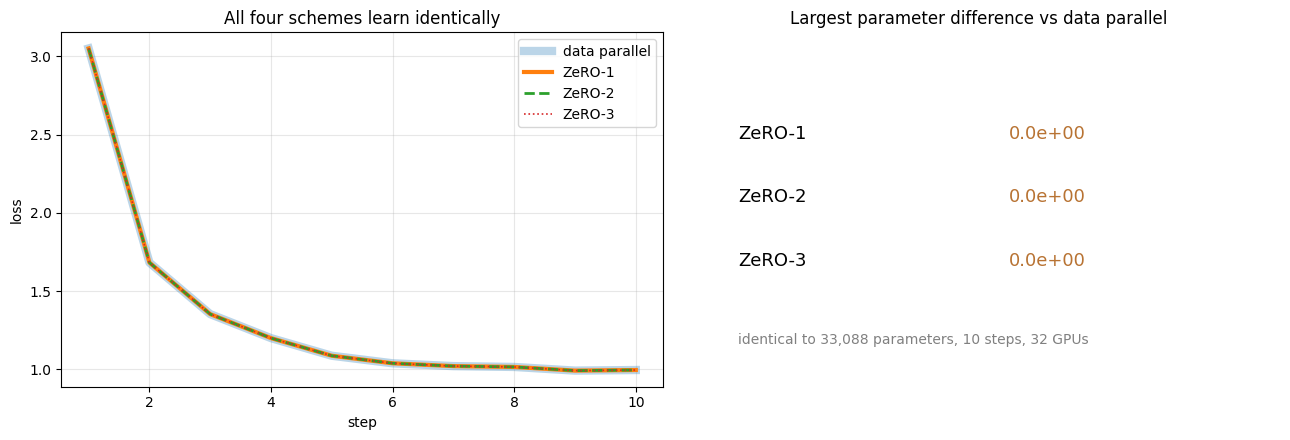

In [33]:
# ==========================================================================
# STEP 12 - PLOTS
#
#   Plots 1 and 2 are the EVIDENCE the implementation is correct.
#   Plots 3 and 4 are the RESULT.
# ==========================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

steps = range(1, STEPS + 1)
ax[0].plot(steps, dp_losses, lw=6, alpha=0.30, label="data parallel")
ax[0].plot(steps, z1_losses, lw=3.0, label="ZeRO-1")
ax[0].plot(steps, z2_losses, lw=2.0, ls="--", label="ZeRO-2")
ax[0].plot(steps, z3_losses, lw=1.2, ls=":", label="ZeRO-3")
ax[0].set_xlabel("step"); ax[0].set_ylabel("loss")
ax[0].set_title("All four schemes learn identically")
ax[0].legend(); ax[0].grid(alpha=0.3)

base  = dp.master[0]
diffs = [np.max(np.abs(s.full_theta() - base)) for s in (z1, z2, z3)]

ax[1].axis("off")
ax[1].set_title("Largest parameter difference vs data parallel")
for i, (nm, d) in enumerate(zip(["ZeRO-1", "ZeRO-2", "ZeRO-3"], diffs)):
    ax[1].text(0.10, 0.70 - i*0.18, nm, fontsize=13)
    ax[1].text(0.55, 0.70 - i*0.18, f"{d:.1e}", fontsize=13, color="#B87333")
ax[1].text(0.10, 0.12,
           f"identical to {model.n_params:,} parameters, {STEPS} steps, {N_GPUS} GPUs",
           fontsize=10, color="grey")
plt.tight_layout(); plt.show()

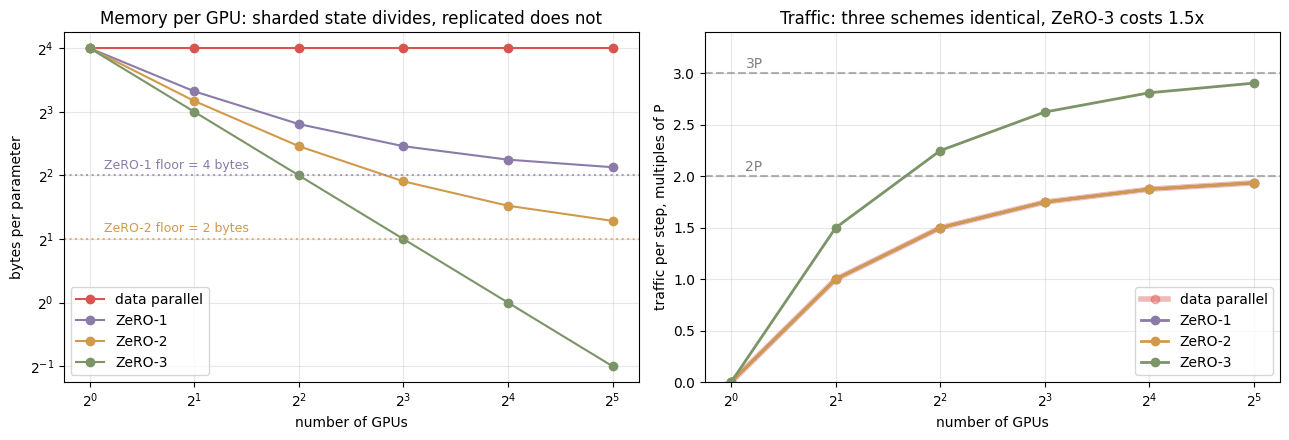

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
names  = ["data parallel", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
colors = ["#D9534F", "#8B7BA8", "#D19A4A", "#7C9468"]
Ns = SWEEP

# ---- plot 3: memory vs N, log-log ----
for i, (nm, c) in enumerate(zip(names, colors)):
    ax[0].plot(Ns, [mem[n][i] for n in Ns], "o-", color=c, label=nm)

ax[0].axhline(4, color="#8B7BA8", ls=":", alpha=0.7)
ax[0].axhline(2, color="#D19A4A", ls=":", alpha=0.7)
ax[0].text(1.1, 4.3, "ZeRO-1 floor = 4 bytes", fontsize=9, color="#8B7BA8")
ax[0].text(1.1, 2.15, "ZeRO-2 floor = 2 bytes", fontsize=9, color="#D19A4A")
ax[0].set_xscale("log", base=2); ax[0].set_yscale("log", base=2)
ax[0].set_xlabel("number of GPUs"); ax[0].set_ylabel("bytes per parameter")
ax[0].set_title("Memory per GPU: sharded state divides, replicated does not")
ax[0].legend(); ax[0].grid(alpha=0.3, which="both")

# ---- plot 4: traffic vs N ----
for i, (nm, c) in enumerate(zip(names, colors)):
    ax[1].plot(Ns, [traf[n][i] for n in Ns], "o-", color=c,
               lw=4 if i == 0 else 2, alpha=0.4 if i == 0 else 1.0, label=nm)

ax[1].axhline(2, color="grey", ls="--", alpha=0.6)
ax[1].axhline(3, color="grey", ls="--", alpha=0.6)
ax[1].text(1.1, 2.05, "2P", fontsize=10, color="grey")
ax[1].text(1.1, 3.05, "3P", fontsize=10, color="grey")
ax[1].set_xscale("log", base=2)
ax[1].set_xlabel("number of GPUs"); ax[1].set_ylabel("traffic per step, multiples of P")
ax[1].set_title("Traffic: three schemes identical, ZeRO-3 costs 1.5x")
ax[1].set_ylim(0, 3.4); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()